In [10]:
# Pipeline completo: preprocesamiento, KMeans(k=5), PCA(2/3), gráficos y resumen de clusters
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# 1. Cargar datos
df = pd.read_csv("data//clientes.csv")

# 2. Columnas a usar
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# 3. Pipeline de preprocesamiento
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
], remainder="drop")

# 4. Pipeline completo con KMeans(k=5)
k = 5
pipeline = Pipeline([
    ("prep", preprocessor),
    ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=50))
])

# 5. Ajustar pipeline y obtener etiquetas
X = df[num_cols + cat_cols]
pipeline.fit(X)
labels = pipeline.named_steps["kmeans"].labels_
df["cluster_k5"] = labels

# 6. Obtener matriz preprocesada para PCA/TSNE
X_transformed = pipeline.named_steps["prep"].transform(X)

# 7. PCA 2 componentes
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_transformed)
df["PC1"] = X_pca2[:,0]
df["PC2"] = X_pca2[:,1]

# 8. PCA 3 componentes
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_transformed)
df["PC1_3"] = X_pca3[:,0]
df["PC2_3"] = X_pca3[:,1]
df["PC3_3"] = X_pca3[:,2]

# 9. t-SNE (opcional para 2D)
pca_pre = PCA(n_components=min(30, X_transformed.shape[1]), random_state=42)
X_pca_pre = pca_pre.fit_transform(X_transformed)
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca_pre)
df["TSNE1"] = X_tsne[:,0]
df["TSNE2"] = X_tsne[:,1]

# 10. Funciones de resumen por cluster
def cluster_numeric_summary(df, cluster_col, num_cols):
    return df.groupby(cluster_col)[num_cols].agg(["count","mean","std"]).round(3)

def cluster_top_categories(df, cluster_col, cat_cols, top_n=3):
    result = {}
    for c in sorted(df[cluster_col].unique()):
        sub = df[df[cluster_col]==c]
        top = {}
        for col in cat_cols:
            vc = sub[col].value_counts(normalize=True).head(top_n)
            top[col] = "; ".join([f"{idx} ({round(val*100,1)}%)" for idx,val in vc.items()])
        result[c] = top
    return pd.DataFrame(result).T

# 11. Resúmenes
numeric_summary = cluster_numeric_summary(df, "cluster_k5", num_cols)
top_categories = cluster_top_categories(df, "cluster_k5", cat_cols, top_n=3)

# 12 visulizar resultados
print(numeric_summary)
print(top_categories)

# 13. Guardar resultados
df.to_csv("result//clientes_cluster_k5_with_pca.csv", index=False)
numeric_summary.to_csv("result//cluster_k5_numeric_summary.csv")
top_categories.to_csv("result//cluster_k5_top_categories.csv")

           Total                   Unit price                 Rating         \
           count     mean      std      count    mean     std  count   mean   
cluster_k5                                                                    
0            235  690.331  152.350        235  80.983  12.424    235  6.584   
1            209  308.763  120.236        209  35.828  14.198    209  7.160   
2            199  126.519   86.887        199  39.146  17.940    199  5.378   
3            165  131.891   82.946        165  34.039  14.820    165  8.638   
4            192  256.606  125.980        192  82.013  11.630    192  7.467   

                  Quantity                
              std    count   mean    std  
cluster_k5                                
0           1.720      235  8.166  1.506  
1           1.555      209  8.359  1.323  
2           0.908      199  3.251  1.772  
3           0.854      165  3.739  1.791  
4           1.482      192  3.021  1.483  
                    Cus

Código para gráficos (PCA 2D, t‑SNE 2D y PCA 3D interactivo)

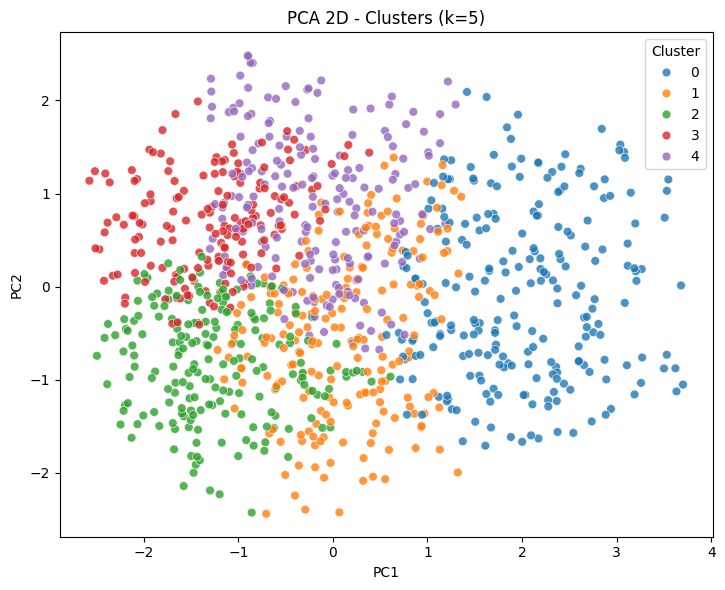

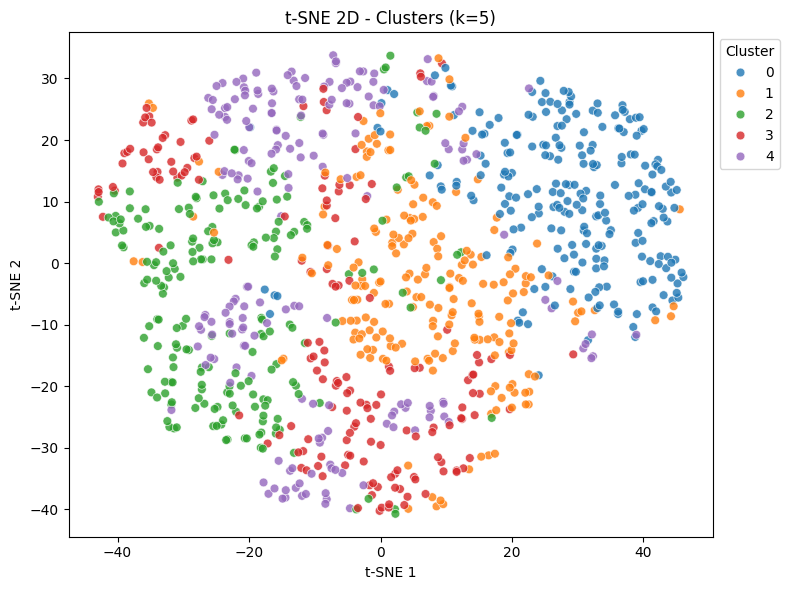

In [8]:
# A. PCA 2D con matplotlib/seaborn
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="cluster_k5", palette="tab10", s=40, alpha=0.8)
plt.title("PCA 2D - Clusters (k=5)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

# B. t-SNE 2D
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="TSNE1", y="TSNE2", hue="cluster_k5", palette="tab10", s=40, alpha=0.8)
plt.title("t-SNE 2D - Clusters (k=5)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

# C. PCA 3D interactivo con Plotly (centroides proyectados)
# Centroides en espacio preprocesado
kmeans = pipeline.named_steps["kmeans"]
centroids = kmeans.cluster_centers_
centroids_pca3 = pca3.transform(centroids)

fig = px.scatter_3d(df, x="PC1_3", y="PC2_3", z="PC3_3",
                    color="cluster_k5", hover_data=["Invoice ID","Total","Product line"],
                    title="PCA 3D - Clusters (k=5)")
fig.add_trace(go.Scatter3d(x=centroids_pca3[:,0], y=centroids_pca3[:,1], z=centroids_pca3[:,2],
                           mode="markers", marker=dict(size=8, color="black", symbol="x"),
                           name="Centroides"))
fig.update_layout(width=1000, height=700, legend_title_text="Cluster")
fig.show()

In [13]:
# Revisión de características de los clusters (K = 5): Tamaños y medias clave

# 1. Cargar datos clusterizados
df = pd.read_csv("result//clientes_cluster_k5_with_pca.csv")

# 2. Definir funciones de resumen
def cluster_numeric_summary(df, cluster_col, num_cols):
    return df.groupby(cluster_col)[num_cols].agg(["count", "mean", "std"]).round(2)

# 3. Columnas numéricas
numeric_cols = ["Total", "Unit price", "Rating", "Quantity"]

# 4. Generar resumen numérico
numeric_summary = cluster_numeric_summary(df, "cluster_k5", numeric_cols)

# 5. Exportar a CSV (opcional)
# numeric_summary.to_csv("result//cluster_k5_numeric_summary.csv")

# 6. Mostrar resumen
print(numeric_summary)

           Total                 Unit price               Rating              \
           count    mean     std      count   mean    std  count  mean   std   
cluster_k5                                                                     
0            235  690.33  152.35        235  80.98  12.42    235  6.58  1.72   
1            209  308.76  120.24        209  35.83  14.20    209  7.16  1.55   
2            199  126.52   86.89        199  39.15  17.94    199  5.38  0.91   
3            165  131.89   82.95        165  34.04  14.82    165  8.64  0.85   
4            192  256.61  125.98        192  82.01  11.63    192  7.47  1.48   

           Quantity              
              count  mean   std  
cluster_k5                       
0               235  8.17  1.51  
1               209  8.36  1.32  
2               199  3.25  1.77  
3               165  3.74  1.79  
4               192  3.02  1.48  


Optimización: prueba UMAP para visualización alternativa, crear embeddings para la columna combinada  y valida estabilidad de clusters con ARI entre ejecuciones.

ARI entre ejecuciones: 0.9576


e:\prj\env_supermarket\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


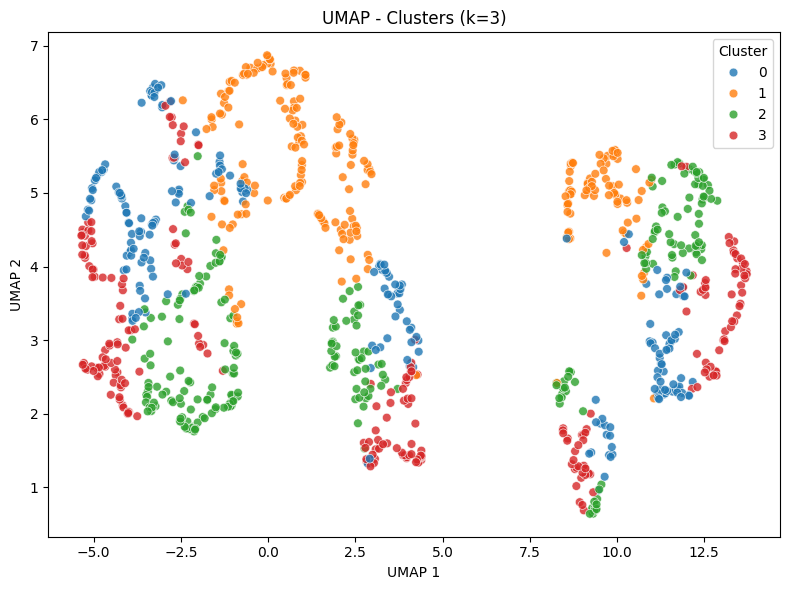

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
# %pip install umap-learn
import umap as umap
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos
df = pd.read_csv("data//clientes.csv")

# 2. Columnas
num_cols = ["Total", "Unit price", "Rating", "Quantity"]
cat_cols = ["Customer type", "Gender", "Product line", "Payment"]

# 3. Crear columna combinada
df["combo"] = df[cat_cols].astype(str).agg("_".join, axis=1)

# 4. Embeddings para columna combinada
vectorizer = CountVectorizer()
combo_vec = vectorizer.fit_transform(df["combo"])
svd = TruncatedSVD(n_components=2, random_state=42)
combo_embed = svd.fit_transform(combo_vec)

# 5. Escalar numéricas
scaler = StandardScaler()
num_scaled = scaler.fit_transform(df[num_cols])

# 6. Matriz final
X = np.hstack([num_scaled, combo_embed])

# 7. KMeans con dos semillas distintas
k = 4
km1 = KMeans(n_clusters=k, random_state=42, n_init=10)
km2 = KMeans(n_clusters=k, random_state=99, n_init=10)
labels1 = km1.fit_predict(X)
labels2 = km2.fit_predict(X)

# 8. Validación de estabilidad
ari = adjusted_rand_score(labels1, labels2)
print(f"ARI entre ejecuciones: {ari:.4f}")

# 9. Visualización con UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

# 10. Graficar UMAP con clusters
df["cluster_k3"] = labels1
df["UMAP1"] = X_umap[:,0]
df["UMAP2"] = X_umap[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="UMAP1", y="UMAP2", hue="cluster_k4", palette="tab10", s=40, alpha=0.8)
plt.title("UMAP - Clusters (k=4)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()